# Fund Workstation

### Setting Up the Environment

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']

#### Load Data via .json

In [2]:
test = load_saved_json(folder_path=r"input")
funds = init_funds(test)


In [ ]:
port = load_saved_json(folder_path=r"input\portfolio")
port = init_funds(port)
funds = funds | port

#### Load Data via .csv

In [ ]:
# Use for manually update csv data and merge with json file 

csv_fund = input_monthly_returns(r"RETURN DATA.csv")



#### GPT Input Factsheet

In [ ]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\re-run",save=True)
gpt_fund = init_funds(gpt_fund)

In [ ]:
port = load_saved_json(folder_path=r"input\portfolio")
port = init_funds(port)
funds = gpt_fund | port

In [ ]:
# Target the files with "No Performance Found", and re-run the analysis again
rerun_no_perf_files(folder_path=r"input\worth_a_look",save=True)

#### Process Input

In [ ]:
# Use the former file's performance data to update the latter one
funds = merge_funds(csv_fund, funds)

In [ ]:
funds = csv_fund | funds

#### Save the Changes

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\test")

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

### Compare Multiple Funds

In [ ]:
df = compare_funds(funds)
df = df[~df["Name"].isin(our_index)].reset_index(drop=True)
df

In [ ]:
# Combine all conditions in a single filter
mask = (df["Sharpe Ratio"] > 1) & (df["Annualized Return"] > 0.1) & (df["AUM (in Mn USD)"] > 10) 

# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", 
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]

# Then, select only the columns you want
df['Worth a Look'] = mask
filtered = df[["Worth a Look","Name", "Location","Strategy", "AUM (in Mn USD)", "Sharpe Ratio", "Annualized Return", "Max Drawdown","Description"]]
filtered

In [ ]:
max_row = df.loc[df["Inception Date"].idxmax()]
print(max_row)
min_row = df.loc[df["Latest Date"].idxmin()]
print(min_row)

#### Save it to CSV

In [ ]:
filtered.to_csv("output/funds_comparison.csv", index=False)

#### Print a list of worth looking funds

In [ ]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

#### Compare Performance Table

In [ ]:
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI WORLD'], benchmark_name = "MSCI\nWorld" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [8]:

# funds_to_be_plot = subset_of_funds(funds, worth_looking)
start_month = "2020-12"
end_month = "2025-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="default",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=True,
    toggle=True
    )


### Correlation Heat Map

In [ ]:
# Correlation heatmap
list_to_plot = our_portfolio + ['BASSWOOD']
print(list_to_plot)
funds_to_be_plot = subset_of_funds(funds, list_to_plot)
start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

### Summary of a Fund

None
No contact info


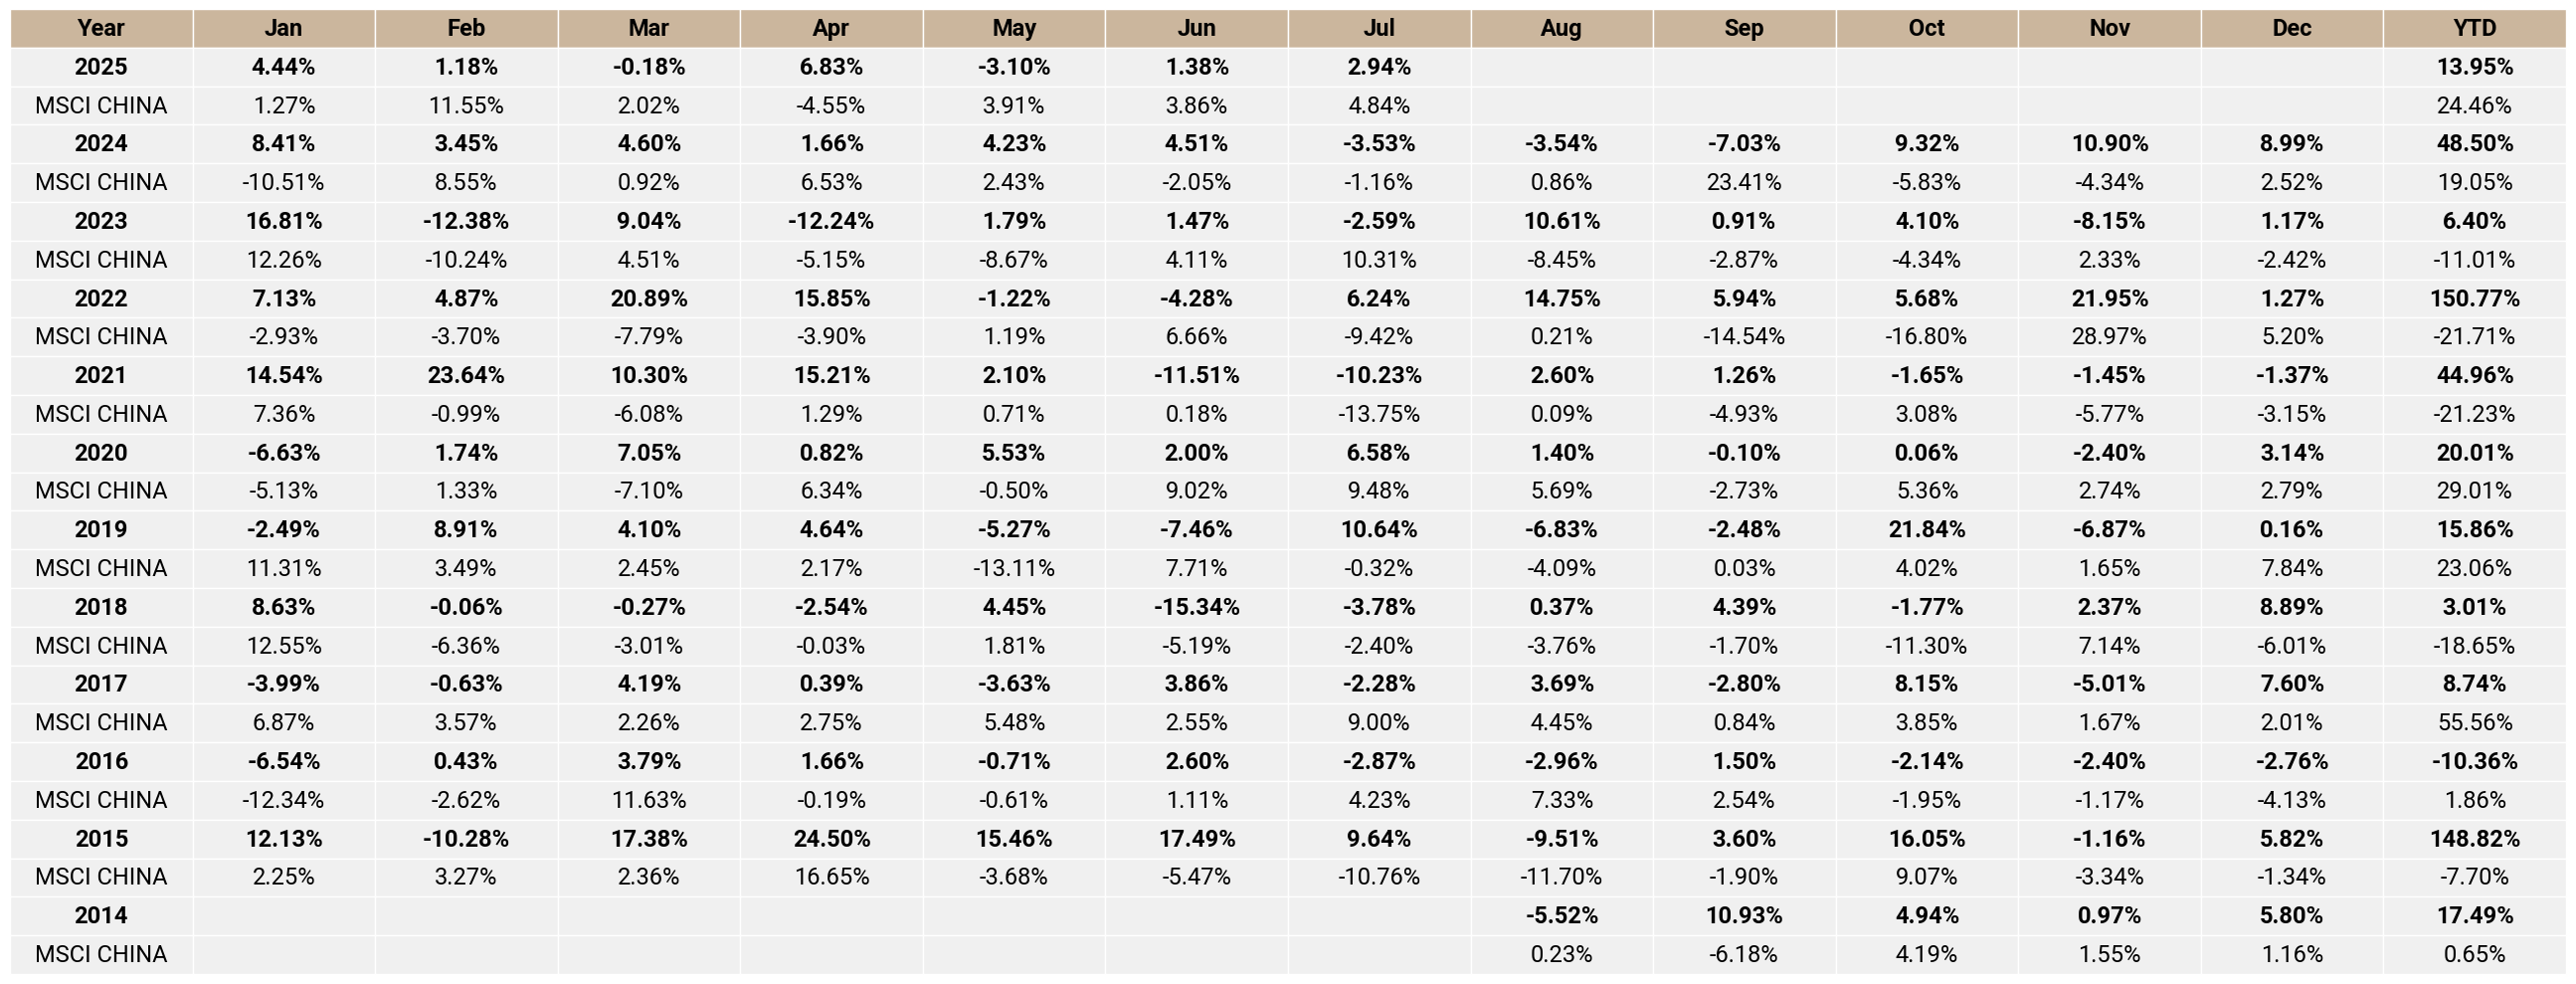

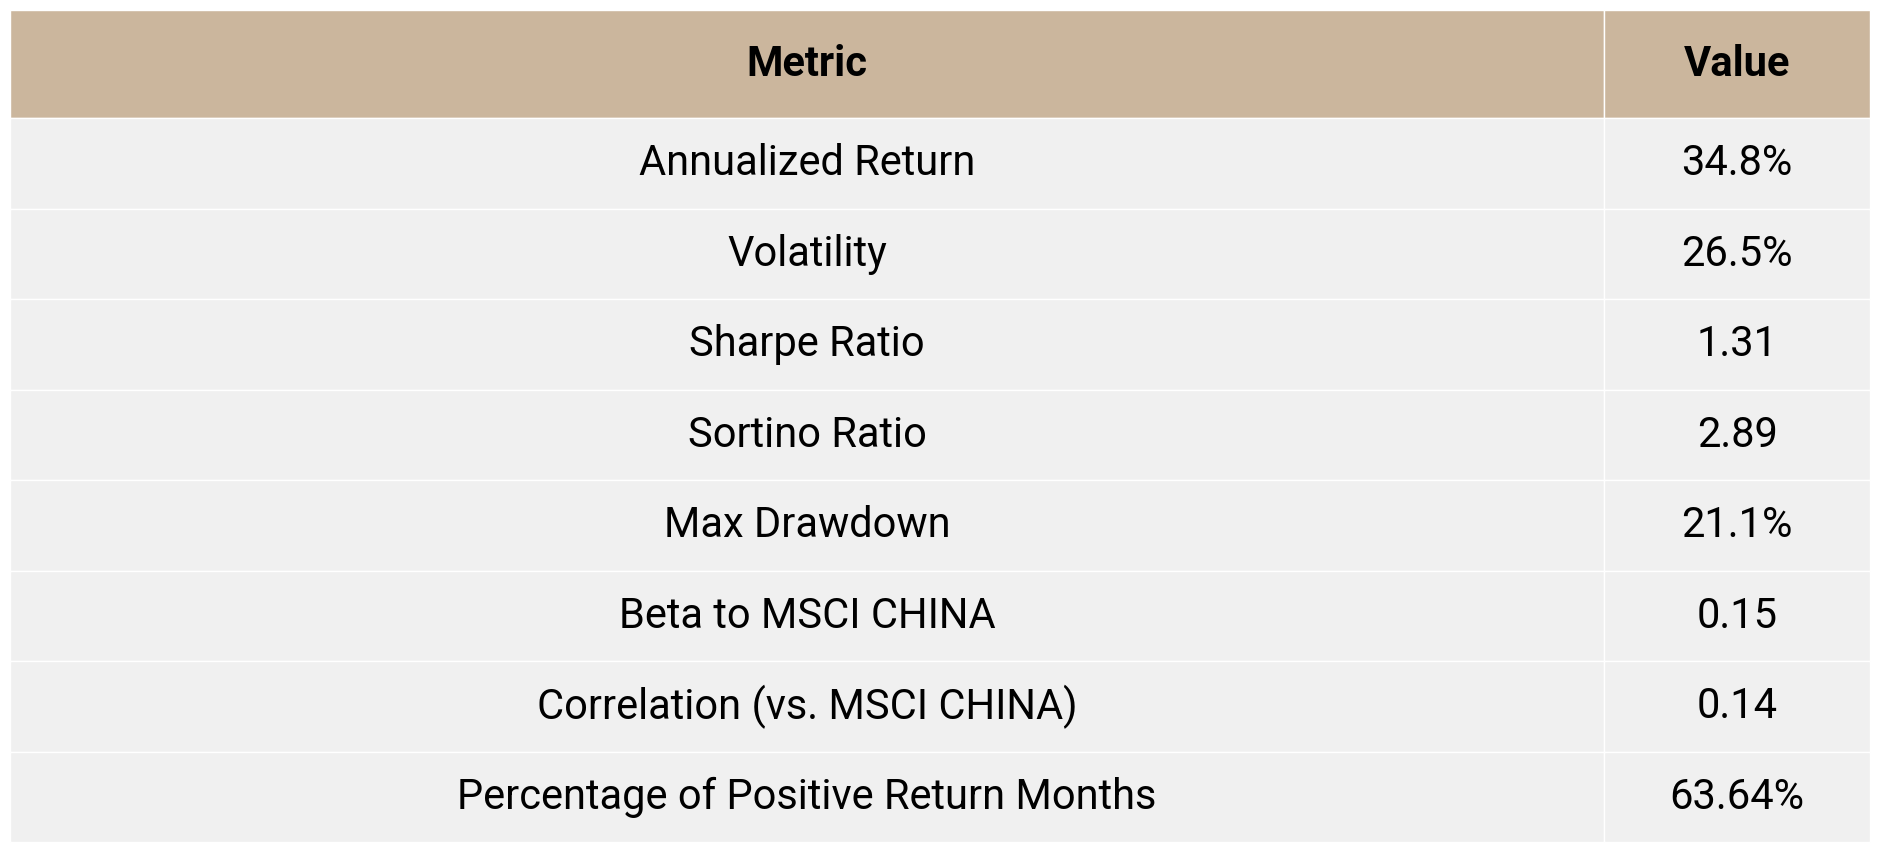

/Users/user/Documents/Python project/fofproject/src/fofproject/fund.py:1459: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [3]:
funds['HAO'].summary_of_a_fund(benchmark_fund=funds['MSCI CHINA'],language="en",save = True)

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )

#### Efficient Frontier Analysis

In [15]:
remove_list = ['E20', 'PERSEVERANCE']

for i, k in enumerate(our_portfolio):
    if k in remove_list:
        our_portfolio.pop(i)
print(our_portfolio)


funds_to_be_plot = subset_of_funds(funds, our_portfolio)

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT CHINA', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'NEO IVY', 'JH BIOTECH']


In [16]:
# Choose Mode between "Maximum Sharpe", "Minimum Variance", "Target Return"
fig, weights, stats = minimum_variance_analysis(funds=funds_to_be_plot, mode="Maximum Sharpe", target_return=0.14, title=None)
print(weights)
print(stats)

AttributeError: 'NoneType' object has no attribute 'monthly_returns'